In [44]:
from google.colab import files
uploaded = files.upload()


Saving telco_gold.csv to telco_gold (1).csv


In [45]:
import pandas as pd
import sqlalchemy as sa;



In [58]:
import pandas as pd
import seaborn as sns


In [59]:
import matplotlib.pyplot as plt


In [60]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [47]:
bool_cols = [
    "is_senior",
    "has_multiple_lines",
    "is_long_term_contract",
    "is_autopay",
    "churn_flag"
]

for col in bool_cols:
    df[col] = df[col].map({"t": True, "f": False})


In [48]:
##Handle missing values

df = df.dropna(subset=["totalcharges"])


In [49]:
##Profile the data
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerid                 7032 non-null   object 
 1   gender                     7032 non-null   object 
 2   seniorcitizen              7032 non-null   int64  
 3   partner                    7032 non-null   object 
 4   dependents                 7032 non-null   object 
 5   tenure                     7032 non-null   int64  
 6   phoneservice               7032 non-null   object 
 7   multiplelines              7032 non-null   object 
 8   internetservice            7032 non-null   object 
 9   onlinesecurity             7032 non-null   object 
 10  onlinebackup               7032 non-null   object 
 11  deviceprotection           7032 non-null   object 
 12  techsupport                7032 non-null   object 
 13  streamingtv                7032 non-null   object 
 1

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,churn,tenure_group,charge_group,is_senior,has_multiple_lines,is_long_term_contract,is_autopay,lifetime_revenue_estimate,avg_monthly_revenue,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,0-6 months,<30,False,False,False,False,29.85,29.850000,False
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,25-48 months,30-60,False,False,True,False,1936.30,55.573529,False
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,0-6 months,30-60,False,False,False,False,107.70,54.075000,True
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,25-48 months,30-60,False,False,True,True,1903.50,40.905556,False
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,0-6 months,60-90,False,False,False,False,141.40,75.825000,True


In [50]:
df["churn_flag"].mean()


np.float64(0.26578498293515357)

In [51]:
df["churn_flag"].value_counts()

,count
churn_flag,
False,5163
True,1869


In [52]:
df.groupby("contract")["churn_flag"].mean().sort_values()


,churn_flag
contract,
Two year,0.028487
One year,0.112772
Month-to-month,0.427097


In [53]:
df.groupby("tenure_group")["churn_flag"].mean().sort_values()


,churn_flag
tenure_group,
49+ months,0.095132
25-48 months,0.203890
13-24 months,0.287109
7-12 months,0.358865
0-6 months,0.533333


In [54]:
df.groupby("internetservice")["churn_flag"].mean().sort_values()


,churn_flag
internetservice,
No,0.074342
DSL,0.189983
Fiber optic,0.418928


In [55]:
df.groupby("paymentmethod")["churn_flag"].mean().sort_values()


,churn_flag
paymentmethod,
Credit card (automatic),0.152531
Bank transfer (automatic),0.167315
Mailed check,0.192020
Electronic check,0.452854


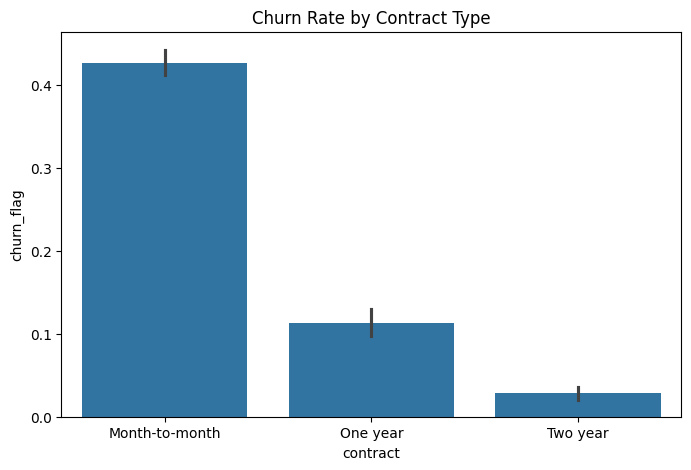

In [61]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="contract", y="churn_flag")
plt.title("Churn Rate by Contract Type")
plt.show()

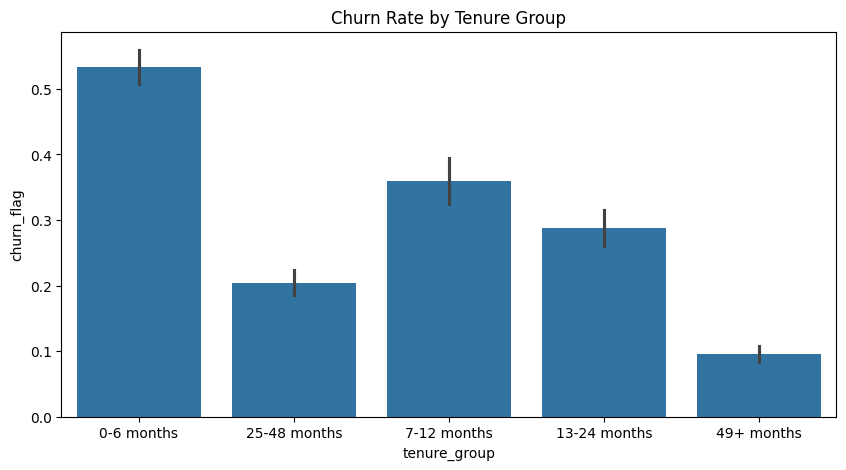

In [62]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="tenure_group", y="churn_flag")
plt.title("Churn Rate by Tenure Group")
plt.show()


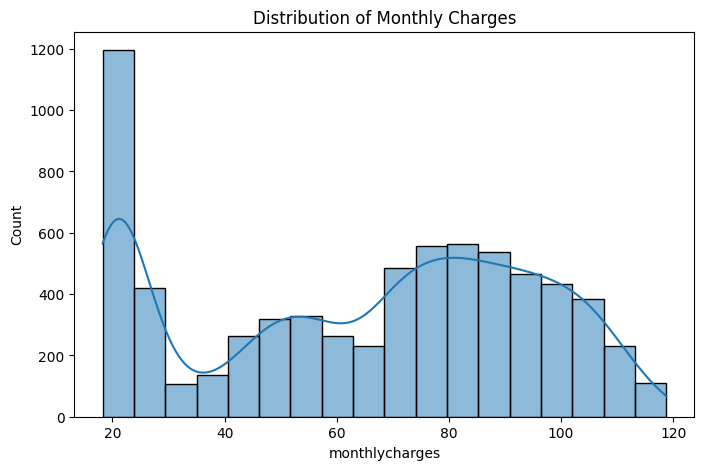

In [63]:
plt.figure(figsize=(8,5))
sns.histplot(df["monthlycharges"], kde=True)
plt.title("Distribution of Monthly Charges")
plt.show()


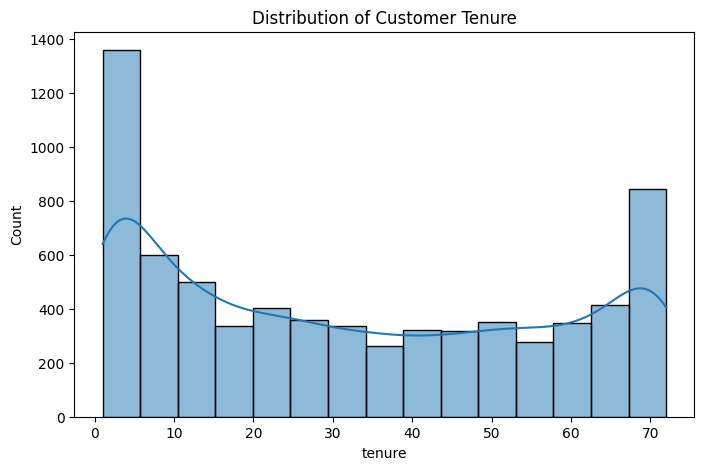

In [64]:
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], kde=True)
plt.title("Distribution of Customer Tenure")
plt.show()


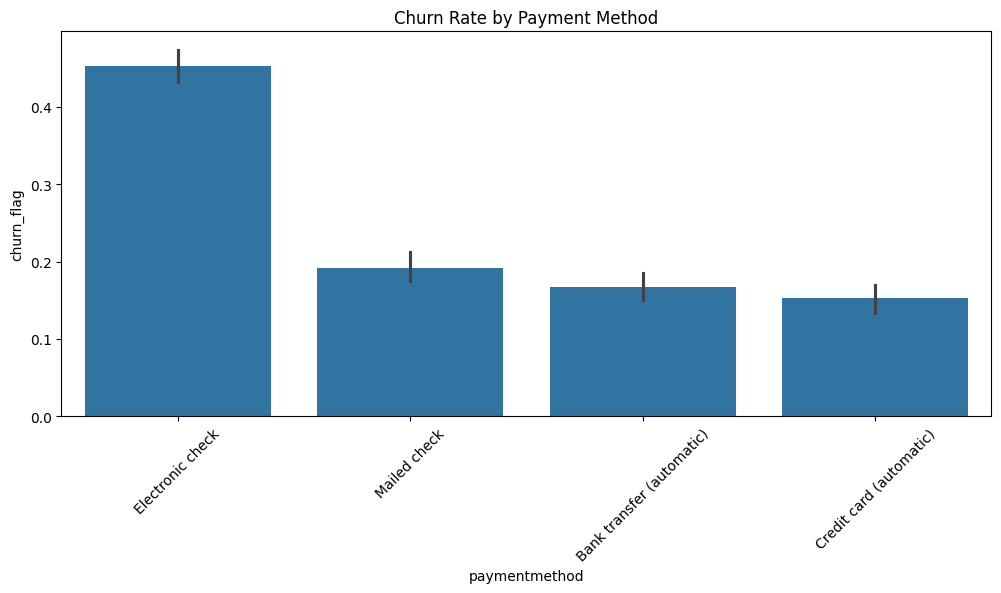

In [65]:
plt.figure(figsize=(12,5))
sns.barplot(data=df, x="paymentmethod", y="churn_flag")
plt.xticks(rotation=45)
plt.title("Churn Rate by Payment Method")
plt.show()


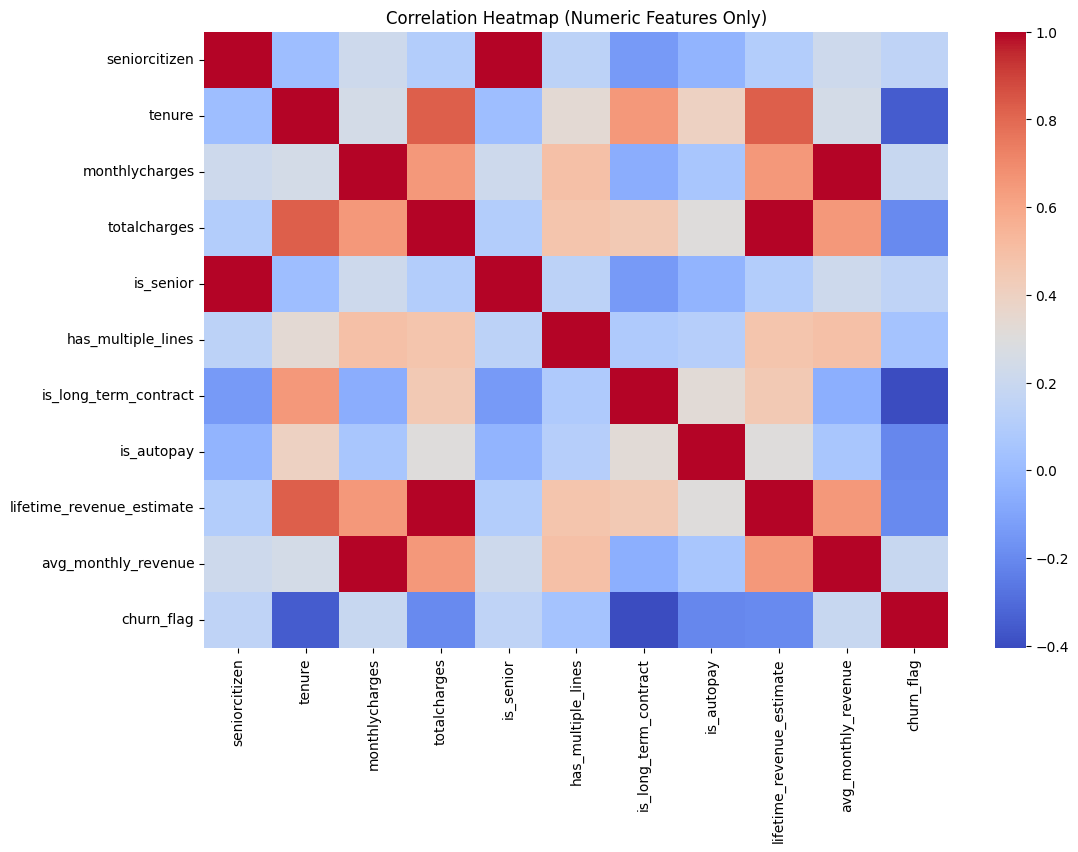

In [67]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=["int64", "float64", "bool"])

sns.heatmap(numeric_df.corr(), cmap="coolwarm", annot=False)

plt.title("Correlation Heatmap (Numeric Features Only)")
plt.show()



In [68]:
summary = pd.DataFrame({
    "Overall Churn Rate": [df["churn_flag"].mean()],
    "Avg Monthly Charges (Churned)": [df[df["churn_flag"]==1]["monthlycharges"].mean()],
    "Avg Monthly Charges (Stayed)": [df[df["churn_flag"]==0]["monthlycharges"].mean()],
    "Avg Tenure (Churned)": [df[df["churn_flag"]==1]["tenure"].mean()],
    "Avg Tenure (Stayed)": [df[df["churn_flag"]==0]["tenure"].mean()]
})

summary.T


,0
Overall Churn Rate,0.265785
Avg Monthly Charges (Churned),74.441332
Avg Monthly Charges (Stayed),61.307408
Avg Tenure (Churned),17.979133
Avg Tenure (Stayed),37.650010


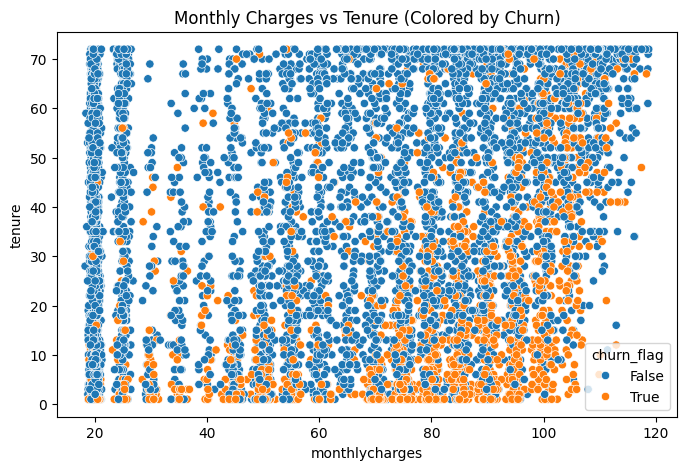

In [69]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="monthlycharges", y="tenure", hue="churn_flag")
plt.title("Monthly Charges vs Tenure (Colored by Churn)")
plt.show()


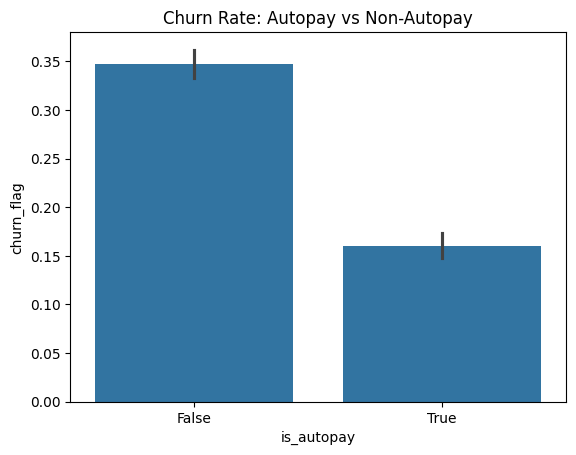

In [70]:
sns.barplot(data=df, x="is_autopay", y="churn_flag")
plt.title("Churn Rate: Autopay vs Non-Autopay")
plt.show()


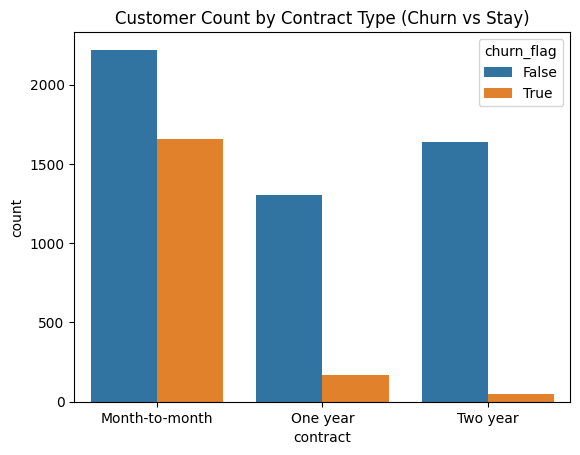

In [71]:
sns.countplot(data=df, x="contract", hue="churn_flag")
plt.title("Customer Count by Contract Type (Churn vs Stay)")
plt.show()


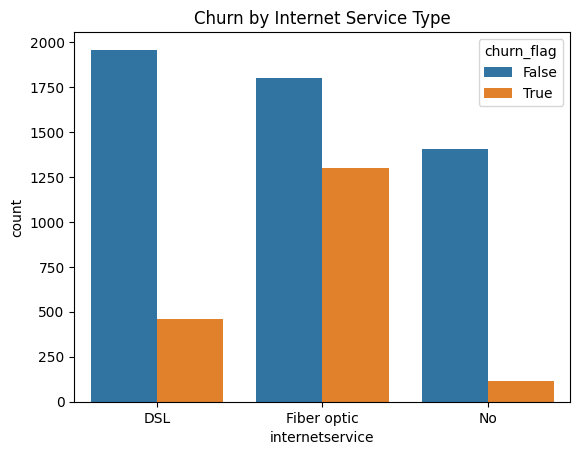

In [72]:
sns.countplot(data=df, x="internetservice", hue="churn_flag")
plt.title("Churn by Internet Service Type")
plt.show()


In [74]:
revenue_at_risk = df[df["churn_flag"]==1]["monthlycharges"].sum()
revenue_at_risk
print(f"Revenue at Risk: ${revenue_at_risk:.2f}")

Revenue at Risk: $139130.85


In [75]:
avg_revenue_at_risk = df[df["churn_flag"]==1]["avg_monthly_revenue"].mean()


In [77]:
high_risk = df.sort_values("monthlycharges", ascending=False).head(10)
high_risk[["customerid", "monthlycharges", "tenure", "contract"]]


,customerid,monthlycharges,tenure,contract
4586,7569-NMZYQ,118.75,72,Two year
2115,8984-HPEMB,118.65,71,Two year
4804,5734-EJKXG,118.60,61,One year
3896,5989-AXPUC,118.60,68,Two year
5127,8199-ZLLSA,118.35,67,One year
6118,9924-JPRMC,118.20,72,Two year
4610,2889-FPWRM,117.80,72,One year
3207,3810-DVDQQ,117.60,72,Two year
6768,9739-JLPQJ,117.50,72,Two year
4875,2302-ANTDP,117.45,48,Month-to-month


In [76]:
df[df["tenure_group"]=="0-6 months"].head(10)


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,churn,tenure_group,charge_group,is_senior,has_multiple_lines,is_long_term_contract,is_autopay,lifetime_revenue_estimate,avg_monthly_revenue,churn_flag
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,0-6 months,<30,False,False,False,False,29.85,29.850,False
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Yes,0-6 months,30-60,False,False,False,False,107.70,54.075,True
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Yes,0-6 months,60-90,False,False,False,False,141.40,75.825,True
20,8779-QRDMV,Male,1,No,No,1,No,No phone service,DSL,No,...,Yes,0-6 months,30-60,True,False,False,False,39.65,39.650,True
22,1066-JKSGK,Male,0,No,No,1,Yes,No,No,No internet service,...,Yes,0-6 months,<30,False,False,False,False,20.15,20.150,True
27,8665-UTDHZ,Male,0,Yes,Yes,1,No,No phone service,DSL,No,...,Yes,0-6 months,30-60,False,False,False,False,30.20,30.200,True
31,4929-XIHVW,Male,1,Yes,No,2,Yes,No,Fiber optic,No,...,No,0-6 months,>90,True,False,False,True,191.00,90.825,False
33,7310-EGVHZ,Male,0,No,No,1,Yes,No,No,No internet service,...,No,0-6 months,<30,False,False,False,True,20.20,20.200,False
34,3413-BMNZE,Male,1,No,No,1,Yes,No,DSL,No,...,No,0-6 months,30-60,True,False,False,True,45.25,45.250,False
36,6047-YHPVI,Male,0,No,No,5,Yes,No,Fiber optic,No,...,Yes,0-6 months,60-90,False,False,False,False,348.50,63.380,True


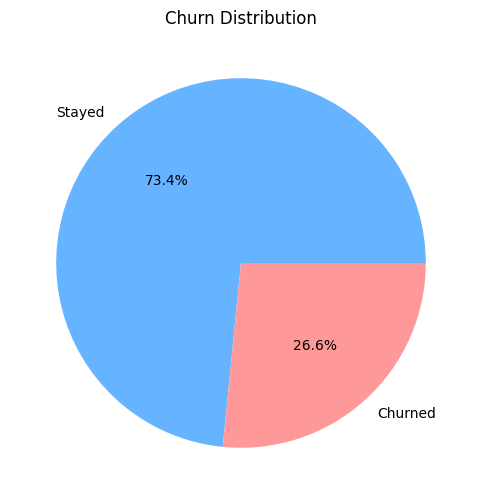

In [78]:
df["churn_flag"].value_counts().plot.pie(
    autopct="%1.1f%%",
    labels=["Stayed", "Churned"],
    figsize=(6,6),
    colors=["#66b3ff", "#ff9999"]
)
plt.title("Churn Distribution")
plt.ylabel("")
plt.show()


In [79]:
df.to_csv("telco_gold_clean.csv", index=False)